# Decision Trees for Classification Task

## Group Members - Group 5

| Name                   | Email |
|:-----------------------|:------|
| Nicolas Martinez Lopez | nmartinezl@unal.edu.co|
| Anna Martina Visone    |avisone@unal.edu.co|
| Miller Barrera González|mbarrerag@unal.edu.co|
| Sergio Castro Vargas   |secastrov@unal.edu.co|

# Libraries

In [82]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd

#  Load dataset

In [83]:
df = pd.read_csv('./classifiers_dataset.csv')
df.head()

,Unnamed: 0,category,age,industries,countryOfCitizenship,selfMade,gender,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,...,population_country,number_of_companies,finalWorth_category,is_founder,is_ceo,is_chairman,is_investor,is_entrepreneur,cpi_country_log,tax_revenue_country_country_log
0,0,Fashion & Retail,74.080767,Consumer Discretionary,France,False,M,1.1,2.715518e+12,65.6,...,67059887.0,75,muy alto,0,1,1,0,0,4.709981,3.226844
1,1,Automotive,51.767283,Consumer Discretionary,United States,True,M,7.5,2.142770e+13,88.2,...,328239523.0,7,muy alto,1,1,0,0,0,4.772716,2.360854
2,2,Technology,59.225188,Technology & Telecommunications,United States,True,M,7.5,2.142770e+13,88.2,...,328239523.0,100,muy alto,1,0,0,0,0,4.772716,2.360854
3,3,Technology,78.628337,Technology & Telecommunications,United States,True,M,7.5,2.142770e+13,88.2,...,328239523.0,5,muy alto,1,0,1,0,0,4.772716,2.360854
4,4,Finance & Investments,92.594114,Financials & Investments,United States,True,M,7.5,2.142770e+13,88.2,...,328239523.0,60,muy alto,0,1,1,0,0,4.772716,2.360854


# Split X and Y

In [84]:
df = df.drop(columns=['Unnamed: 0', 'is_founder', 'is_entrepreneur'], errors='ignore')

In [85]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['finalWorth_category', 'selfMade'])
y = df['selfMade']

# First split: 70% training, 30% for temp (test + validation)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3, # 30% for temp
    random_state=42,
    stratify=y
)

# Second split: temp (30%) into 15% test and 15% validation
X_test, X_val, y_test, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5, # 15% of total (0.5 * 30% = 15%)
    random_state=42,
    stratify=y_temp
)

In [86]:
print(X.columns.tolist())

['category', 'age', 'industries', 'countryOfCitizenship', 'gender', 'cpi_change_country', 'gdp_country', 'gross_tertiary_education_enrollment', 'gross_primary_education_enrollment_country', 'life_expectancy_country', 'total_tax_rate_country', 'population_country', 'number_of_companies', 'is_ceo', 'is_chairman', 'is_investor', 'cpi_country_log', 'tax_revenue_country_country_log']


### Dataset Loading Cell

Here is the code used to load the dataset:

In [87]:
print("Dataset loading cell (9XuqxhhIV8lk):")
print("df = pd.read_csv('./classifiers_dataset.csv')")
print("df.head()")

Dataset loading cell (9XuqxhhIV8lk):
df = pd.read_csv('./classifiers_dataset.csv')
df.head()


### Checking Data Shapes and Target Distribution

Let's check the shapes of the training and testing sets and the value counts of the target variable `y` to understand the data distribution.

In [88]:
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("\nValue counts for y:")
print(y.value_counts())

Shape of X_train: (1846, 18)
Shape of X_test: (396, 18)

Value counts for y:
selfMade
True     1811
False     827
Name: count, dtype: int64


In [89]:
X = df.drop(columns=['finalWorth_category', 'selfMade'])
y = df['selfMade']

# Identify columns

In [90]:
categorical_cols = [
    'industries',
    'countryOfCitizenship',
    'gender',
    'category' # Added 'category' to be one-hot encoded
]

binary_cols = [
    'is_ceo',
    'is_chairman',
    'is_investor'
]

numeric_cols = [
    'age',
    'cpi_change_country',
    'gdp_country',
    'gross_tertiary_education_enrollment',
    'gross_primary_education_enrollment_country',
    'life_expectancy_country',
    'total_tax_rate_country',
    'population_country',
    'number_of_companies',
    'cpi_country_log',
    'tax_revenue_country_country_log'
]

# Prepare dataset

In [91]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('bin', 'passthrough', binary_cols)
    ],
    remainder='passthrough'
)

## Categorical cols

# Create pipeline

In [116]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        criterion='entropy',
        max_depth= 5,            # Limit the maximum depth of the tree
        min_samples_leaf=2,    # Minimum number of samples required to be at a leaf node
        min_samples_split=3    # Minimum number of samples required to split an internal node
    ))
])

### Tree Construction and Training

Here, we fit the Decision Tree model to the training data. The `criterion='entropy'` argument in `DecisionTreeClassifier` makes the splits based on information gain, which is characteristic of the C4.5 algorithm. The tree is constructed by recursively splitting the data to maximize information gain.

In [113]:
# Train the model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', MinMaxScaler(),
                                                  ['age', 'cpi_change_country',
                                                   'gdp_country',
                                                   'gross_tertiary_education_enrollment',
                                                   'gross_primary_education_enrollment_country',
                                                   'life_expectancy_country',
                                                   'total_tax_rate_country',
                                                   'population_country',
                                                   'number_of_companies',
                                                   'cpi_country_log',
                                                   'tax_revenue_country_country_log']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['industries',
                                                   'countryOfCitizenship',
                                                   'gender', 'category']),
                                                 ('bin', 'passthrough',
                                                  ['is_ceo', 'is_chairman',
                                                   'is_investor'])])),
                ('classifier',
                 DecisionTreeClassifier(criterion='entropy', max_depth=3,
                                        min_samples_leaf=2, min_samples_split=3,
                                        random_state=42))])

### Model Evaluation

Now, let's evaluate the performance of the trained model.

In [114]:
from sklearn.metrics import classification_report

y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.97      0.82      0.89       124
        True       0.92      0.99      0.96       272

    accuracy                           0.94       396
   macro avg       0.95      0.91      0.92       396
weighted avg       0.94      0.94      0.94       396



### Visualizing the Decision Tree

To understand how the `DecisionTreeClassifier` made its predictions, we can visualize the tree structure. This can also help in identifying potential overfitting if the tree is too deep or complex.

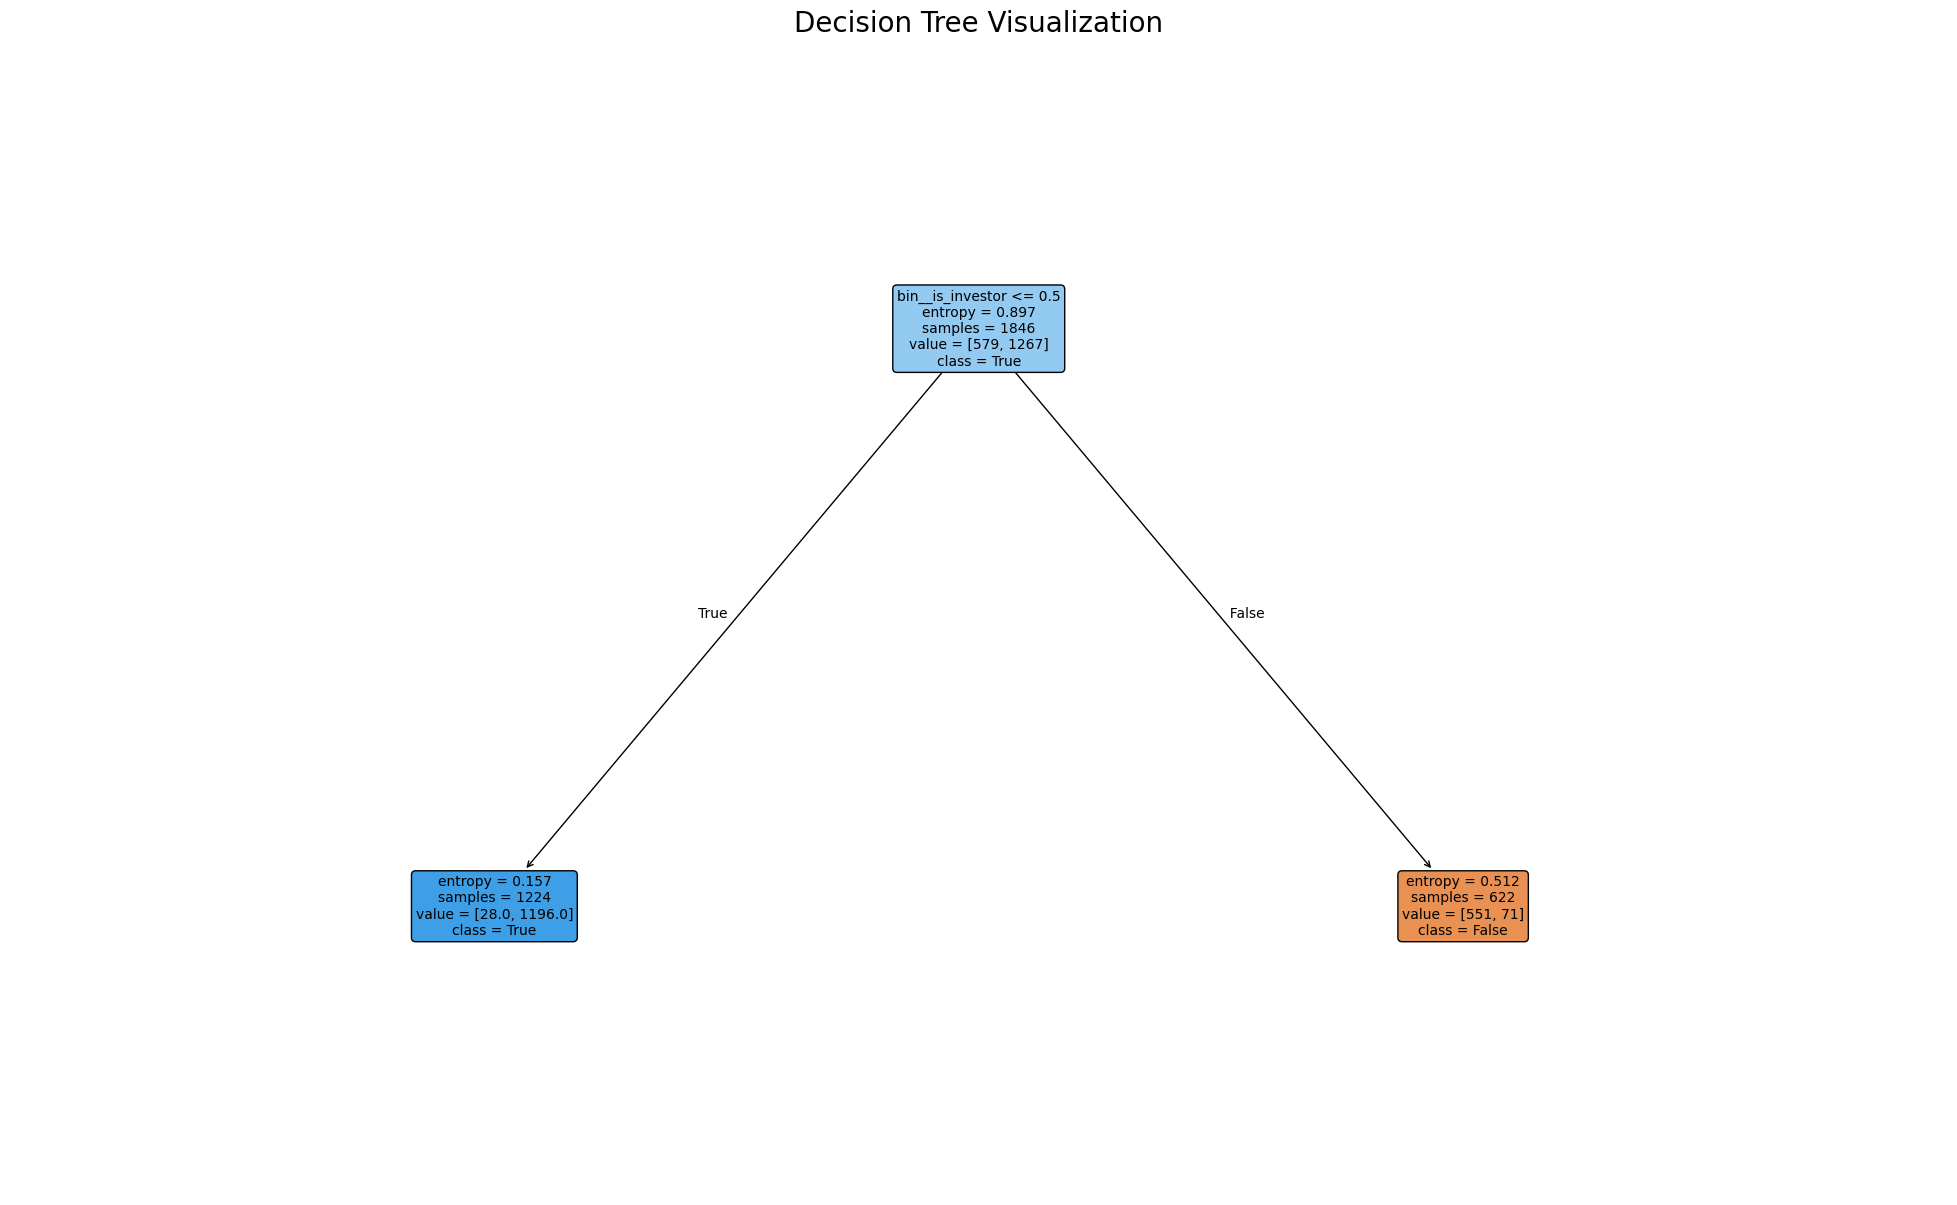

In [95]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Extract the DecisionTreeClassifier from the pipeline
dtc_model = pipeline.named_steps['classifier']

# Get the fitted preprocessor from the pipeline
fitted_preprocessor = pipeline.named_steps['preprocessor']

# Get the feature names after preprocessing
# This method returns the names of all output features from the ColumnTransformer
transformed_feature_names = fitted_preprocessor.get_feature_names_out()

plt.figure(figsize=(25, 15))
plot_tree(dtc_model,
          feature_names=transformed_feature_names, # Use the correct transformed feature names
          class_names=[str(c) for c in dtc_model.classes_.tolist()], # Convert boolean class names to strings
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Visualization', fontsize=20)
plt.show()

### Discussion on Perfect Classification Scores

The `classification_report` shows perfect precision, recall, and f1-score (1.00) for all classes. While this might seem ideal, it often indicates one of the following scenarios:

1.  **Overfitting:** The model might have learned the training data too well, including its noise, making it perform perfectly on the test set because the test set is very similar to the training data or small. A complex tree (as might be visible in the plot above) could suggest this.
2.  **Data Leakage:** Information from the target variable (`finalWorth_category`) might have inadvertently seeped into the feature set (`X`) during data preparation. This allows the model to 'cheat' by using a feature that is directly or indirectly derived from the target.
3.  **Very Separable Dataset:** It's possible that the classes in your dataset are perfectly linearly (or non-linearly) separable, meaning there's a clear boundary that allows the model to distinguish between all classes without error.

Given the context of a real-world dataset, perfect scores are rare. It's recommended to:

*   **Review Feature Engineering:** Double-check all steps where new features were created to ensure no direct or indirect information from `finalWorth_category` was used to create any feature in `X`.
*   **Cross-Validation:** Implement cross-validation to get a more robust estimate of the model's performance on unseen data. This helps assess how well the model generalizes.
*   **Pruning:** Although `criterion='entropy'` is C4.5-like, `sklearn`'s `DecisionTreeClassifier` can still grow a very deep tree. Experiment with pruning parameters like `max_depth`, `min_samples_leaf`, or `ccp_alpha` to simplify the tree and potentially improve generalization, even if it slightly reduces training accuracy.

### Explaining C4.5 Concepts with `DecisionTreeClassifier`

**1. Entropy:**
In a `DecisionTreeClassifier` with `criterion='entropy'`, entropy is used to measure the impurity of a node. A node with high entropy has a mixed distribution of classes, while a node with low entropy is more homogeneous.

**2. Information Gain:**
Information Gain is the reduction in entropy achieved by splitting a node. The algorithm chooses the feature and split point that maximizes information gain at each step. This is implicitly calculated and used by `DecisionTreeClassifier` when `criterion='entropy'`.

**3. Gain Ratio:**
While `DecisionTreeClassifier` directly uses information gain (when `criterion='entropy'`), C4.5 uses Gain Ratio to mitigate a bias that Information Gain has towards features with many possible values. `sklearn`'s `DecisionTreeClassifier` primarily relies on impurity reduction. If explicit Gain Ratio calculations are needed, a custom splitting function would be required or a manual calculation after the tree is built.

**4. Tree Construction:**
The tree is constructed in a top-down, recursive manner. Starting from the root, the algorithm selects the best feature to split the data based on the chosen criterion (entropy/information gain). This process is repeated for each child node until a stopping condition is met (e.g., maximum depth, minimum samples per leaf, or a node becomes pure).

**5. Pruning:**
Pruning is used to reduce the complexity of the decision tree and prevent overfitting. `DecisionTreeClassifier` supports post-pruning through parameters like `ccp_alpha` (Cost-Complexity Pruning) or pre-pruning using parameters like `max_depth`, `min_samples_split`, and `min_samples_leaf`. For example, you can set `max_depth` to limit the tree's depth or `min_samples_leaf` to specify the minimum number of samples a leaf node must have.